In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image


In [7]:
print("Isi train:")
print(os.listdir(train_path)[:10])

print("\nIsi val:")
print(os.listdir(val_path)[:10])

Isi train:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']

Isi val:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


In [8]:
train_classes = sorted(os.listdir(train_path))
val_classes = sorted(os.listdir(val_path))

print("\nJumlah kelas train:", len(train_classes))
print("Jumlah kelas val:", len(val_classes))

print("\nKelas train:")
for i, class_name in enumerate(train_classes):
    print(i, class_name)


Jumlah kelas train: 38
Jumlah kelas val: 38

Kelas train:
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_m

In [9]:
train_counts = {}

for class_name in train_classes:
    class_path = os.path.join(train_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    train_counts[class_name] = len(images)


val_counts = {}

for class_name in val_classes:
    class_path = os.path.join(val_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    val_counts[class_name] = len(images)

In [10]:
df_counts = pd.DataFrame({
    "class": train_classes,
    "train": [train_counts[class_name] for class_name in train_classes],
    "val": [val_counts[class_name] for class_name in train_classes]
})

df_counts["total"] = df_counts["train"] + df_counts["val"]

df_counts

,class,train,val,total
0,Apple___Apple_scab,504,126,630
1,Apple___Black_rot,496,125,621
2,Apple___Cedar_apple_rust,220,55,275
3,Apple___healthy,1316,329,1645
4,Blueberry___healthy,1202,300,1502
5,Cherry_(including_sour)___Powdery_mildew,842,210,1052
6,Cherry_(including_sour)___healthy,684,170,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410,103,513
8,Corn_(maize)___Common_rust_,953,239,1192
9,Corn_(maize)___Northern_Leaf_Blight,788,197,985


In [11]:
print("Total gambar train:", df_counts["train"].sum())
print("Total gambar val:", df_counts["val"].sum())
print("Total seluruh gambar:", df_counts["total"].sum())

Total gambar train: 43444
Total gambar val: 10861
Total seluruh gambar: 54305


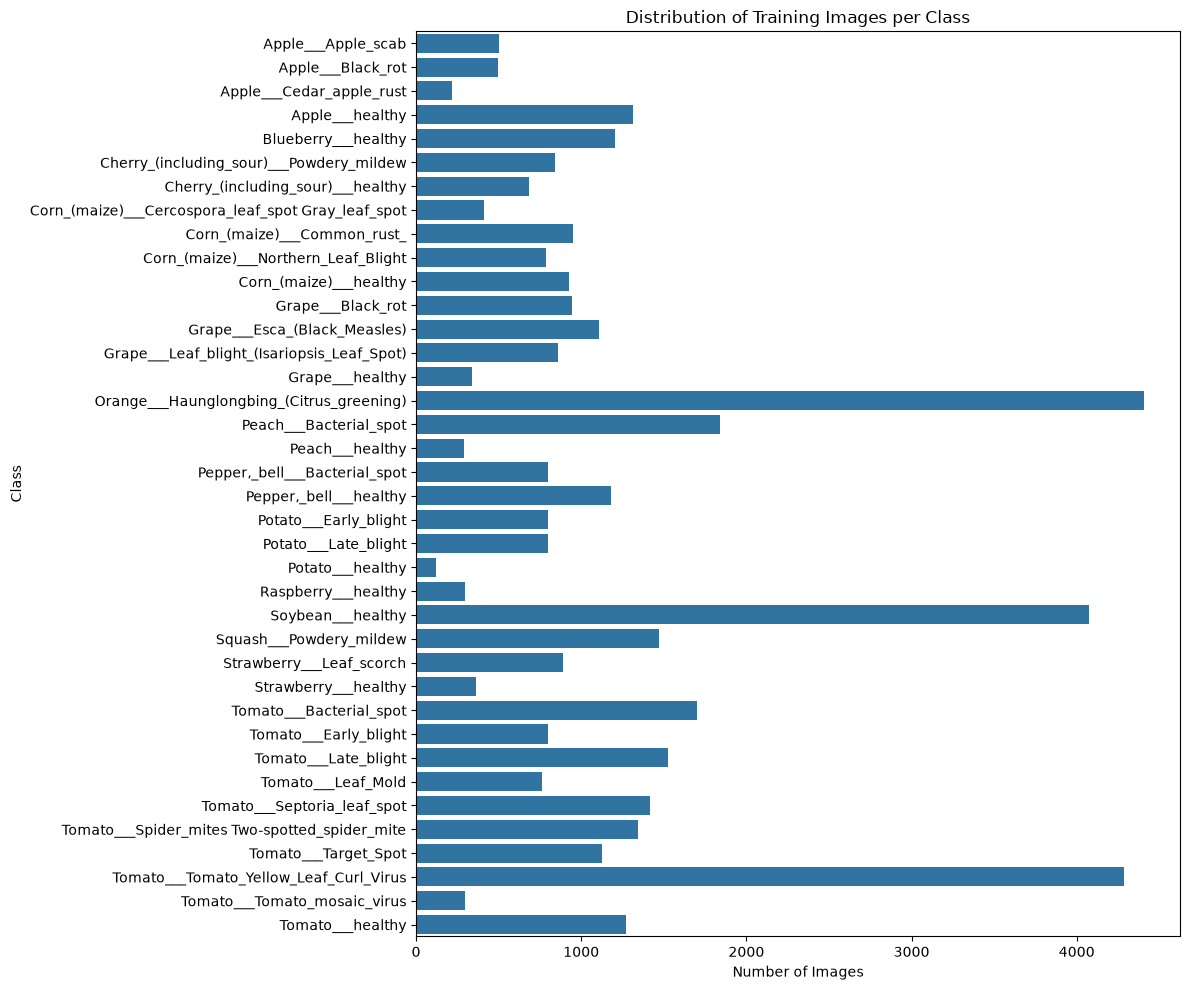

In [12]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=df_counts,
    x="train",
    y="class"
)

plt.title("Distribution of Training Images per Class")
plt.xlabel("Number of Images")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

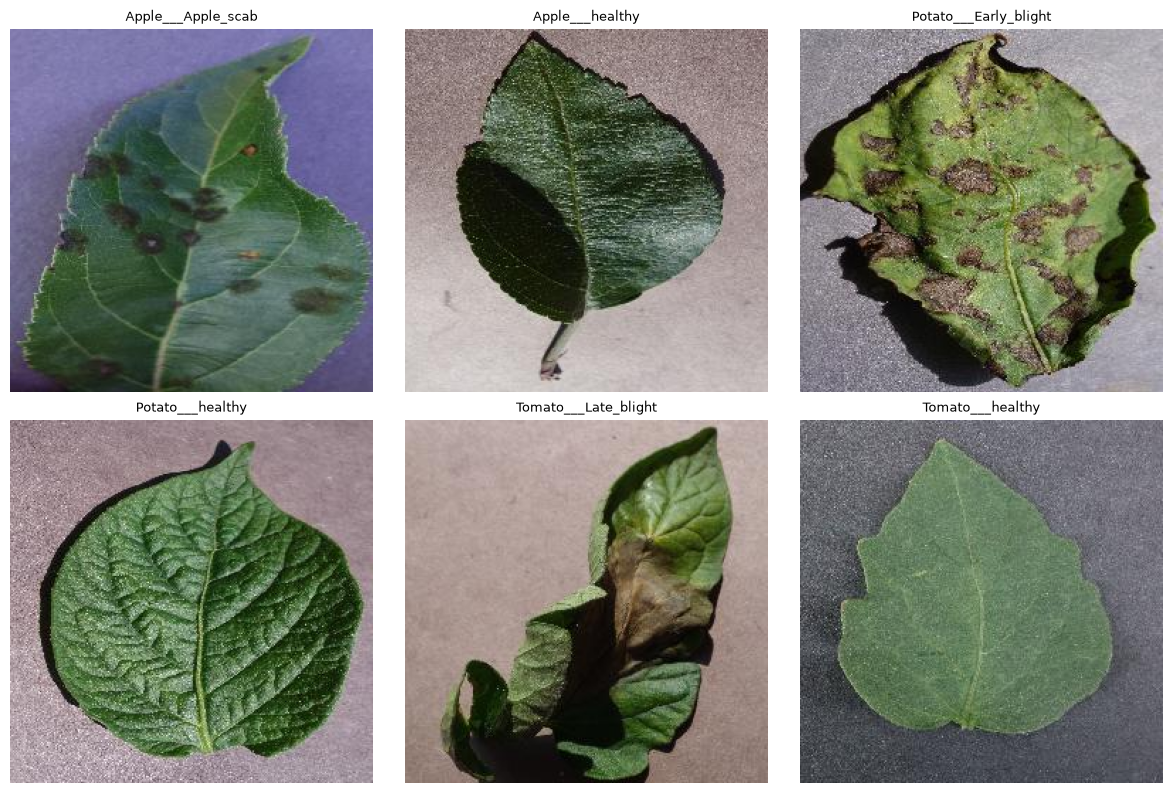

In [13]:
selected_classes = [
    "Apple___Apple_scab",
    "Apple___healthy",
    "Potato___Early_blight",
    "Potato___healthy",
    "Tomato___Late_blight",
    "Tomato___healthy"
]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(train_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
sample_class = train_classes[0]
sample_path = os.path.join(train_path, sample_class)

sample_file = [
    file for file in os.listdir(sample_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

image = Image.open(os.path.join(sample_path, sample_file))

print("Ukuran gambar:", image.size)
print("Mode gambar:", image.mode)

Ukuran gambar: (256, 256)
Mode gambar: RGB
